# 4. Implementing Matrix Factorization

## (b) Data Compression  


### **Objective**  
Explore low-rank **matrix factorization for compression** on a patch of size 50×50 pixels.  

Cases to analyze:  
1. A patch with mainly **a single color**.  
2. A patch with **2–3 different colors**.  
3. A patch with **5 or more different colors**.  

Tasks:  
- Use Gradient Descent for matrix factorization.  
- Vary rank values as: `r = [5, 10, 25, 50]`.  
- For each patch:  
  - Reconstruct using low-rank factors.  
  - Replace reconstructed patch back into the original image (keeping other pixels unchanged).  
  - Plot reconstructed vs original patches.  
- Write **observations** on how reconstruction quality changes with:  
  - Different ranks,  
  - Different patch complexity (colors).  


Importing Libraries


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torchvision
import matplotlib.patches as mpatches

Setting up Device

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():  # For Mac GPUs
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Working on device:", device)

Working on device: cpu


Defining Random Seed

In [3]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

Colored image shape (C,H,W): torch.Size([3, 1365, 2048])
Min pixel value: 0.0
Max pixel value: 1.0


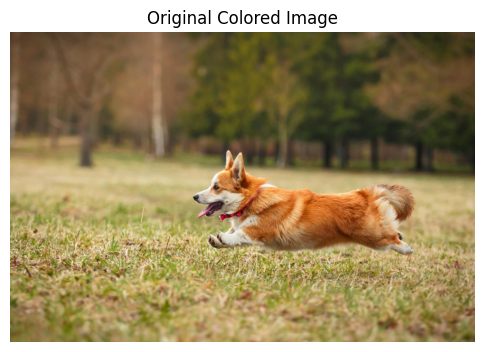

In [4]:
def normalize_image(image_tensor):
    return image_tensor.float() / 255.0


color_img = torchvision.io.read_image(r'C:\Users\Parth Dembla\Downloads\Machine Learning\ES---335-ML-Assignment-2\Task 4\dog.jpg')  # shape: [C, H, W]
color_img = normalize_image(color_img)
print("Colored image shape (C,H,W):", color_img.shape)
print("Min pixel value:", color_img.min().item())
print("Max pixel value:", color_img.max().item())

# Display colored image
plt.figure(figsize=(6,6))
plt.imshow(color_img.permute(1,2,0))  # convert [C,H,W] -> [H,W,C] for matplotlib
plt.title("Original Colored Image")
plt.axis('off')
plt.show()

Cropping The Image

torch.Size([3, 300, 300])


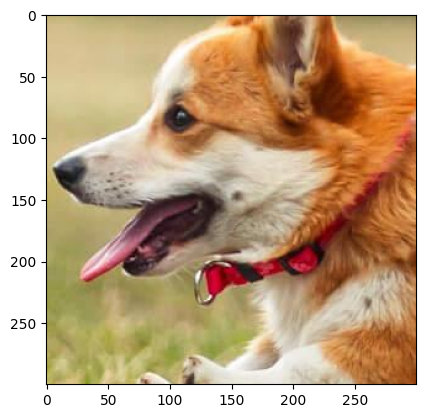

In [5]:
crop = torchvision.transforms.functional.crop(color_img, 600, 800, 300, 300)
color_img = crop
print(color_img.shape)
plt.imshow(color_img.permute(1, 2, 0))

In [6]:
def show_patch(image, top_left, N=50):
    fig, ax = plt.subplots(1,1,figsize=(6,6))
    ax.imshow(image.permute(1,2,0).cpu())
    rect = mpatches.Rectangle((top_left[1], top_left[0]), N, N, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.set_title(f"Selected Patch at {top_left}")
    #ax.axis('off')
    plt.show()

In [7]:
def low_rank_gd(patch, rank, lr=0.01, num_iters=10000):
    C, H, W = patch.shape
    patch_reconstructed = torch.zeros_like(patch)

    for c in range(C):
        X = patch[c]  # [H,W]

        # Initialize U and V
        U = torch.randn(H, rank, device=device, requires_grad=True)
        V = torch.randn(W, rank, device=device, requires_grad=True)

        optimizer = optim.Adam([U, V], lr=lr)

        for it in range(num_iters):
            optimizer.zero_grad()
            X_hat = U @ V.T
            loss = ((X - X_hat) ** 2).mean()
            loss.backward()
            optimizer.step()

            # Print loss every 500 iterations and at the last iteration
            if it % 5000 == 0 or it == num_iters - 1:
                print(f"Channel {c+1}, GD Iteration {it:5d}, Loss={loss.item():.6f}")

        patch_reconstructed[c] = U @ V.T

    return patch_reconstructed


In [8]:
def replace_patch(original_img, reconstructed_patch, top_left):
    img_copy = original_img.clone()
    x, y = top_left
    _, N, _ = reconstructed_patch.shape
    img_copy[:, x:x+N, y:y+N] = reconstructed_patch
    return img_copy

In [9]:
def compute_metrics(X_true, X_pred):
    """Compute RMSE and PSNR over a patch or image"""
    mse = ((X_true - X_pred).pow(2)).mean()
    rmse = torch.sqrt(mse).item()
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse)).item()
    return rmse, psnr

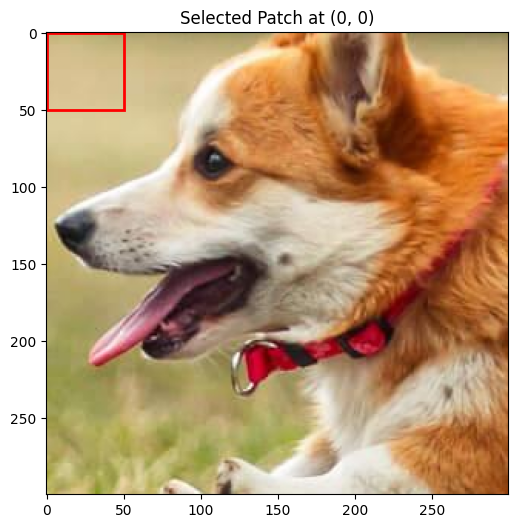


--- Patch: Single color ---
Channel 1, GD Iteration     0, Loss=6.035685
Channel 1, GD Iteration   999, Loss=0.000085
Channel 2, GD Iteration     0, Loss=5.032462
Channel 2, GD Iteration   999, Loss=0.000049
Channel 3, GD Iteration     0, Loss=4.450742
Channel 3, GD Iteration   999, Loss=0.000057
Rank 5: RMSE=0.007992, PSNR=41.95 dB
Channel 1, GD Iteration     0, Loss=10.849456
Channel 1, GD Iteration   999, Loss=0.000211
Channel 2, GD Iteration     0, Loss=10.486377
Channel 2, GD Iteration   999, Loss=0.000045
Channel 3, GD Iteration     0, Loss=12.421770


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0350285].


Channel 3, GD Iteration   999, Loss=0.000049
Rank 10: RMSE=0.010070, PSNR=39.94 dB
Channel 1, GD Iteration     0, Loss=24.868462
Channel 1, GD Iteration   999, Loss=0.000096
Channel 2, GD Iteration     0, Loss=26.485262
Channel 2, GD Iteration   999, Loss=0.000036
Channel 3, GD Iteration     0, Loss=27.444534
Channel 3, GD Iteration   999, Loss=0.000046
Rank 25: RMSE=0.007681, PSNR=42.29 dB
Channel 1, GD Iteration     0, Loss=50.878857
Channel 1, GD Iteration   999, Loss=0.000080
Channel 2, GD Iteration     0, Loss=55.141182
Channel 2, GD Iteration   999, Loss=0.000037
Channel 3, GD Iteration     0, Loss=46.329758
Channel 3, GD Iteration   999, Loss=0.000027
Rank 50: RMSE=0.006918, PSNR=43.20 dB


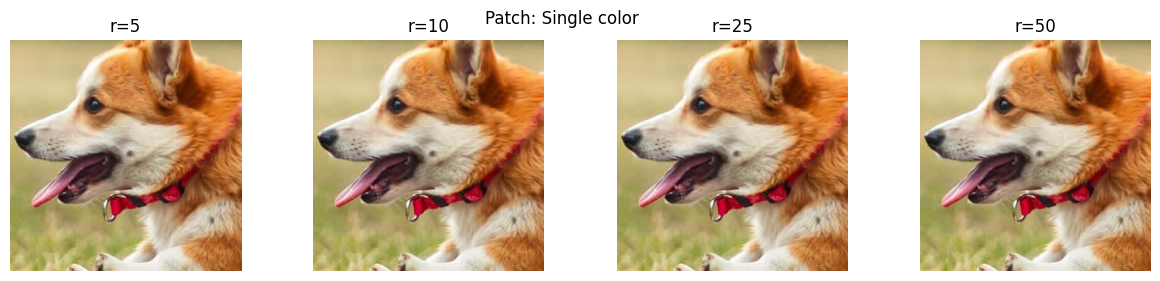

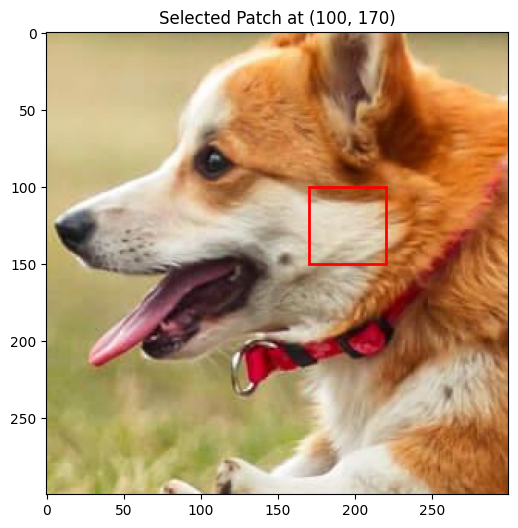


--- Patch: 2-3 colors ---
Channel 1, GD Iteration     0, Loss=6.717894
Channel 1, GD Iteration   999, Loss=0.001428
Channel 2, GD Iteration     0, Loss=5.876317
Channel 2, GD Iteration   999, Loss=0.002618
Channel 3, GD Iteration     0, Loss=5.065874
Channel 3, GD Iteration   999, Loss=0.003432
Rank 5: RMSE=0.049919, PSNR=26.03 dB
Channel 1, GD Iteration     0, Loss=10.761403
Channel 1, GD Iteration   999, Loss=0.001254
Channel 2, GD Iteration     0, Loss=10.923079
Channel 2, GD Iteration   999, Loss=0.002303
Channel 3, GD Iteration     0, Loss=10.304172


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0027733198..1.0].


Channel 3, GD Iteration   999, Loss=0.001973
Rank 10: RMSE=0.042923, PSNR=27.35 dB
Channel 1, GD Iteration     0, Loss=23.540842
Channel 1, GD Iteration   999, Loss=0.000821
Channel 2, GD Iteration     0, Loss=28.517471
Channel 2, GD Iteration   999, Loss=0.001624
Channel 3, GD Iteration     0, Loss=24.241997
Channel 3, GD Iteration   999, Loss=0.001846
Rank 25: RMSE=0.037814, PSNR=28.45 dB
Channel 1, GD Iteration     0, Loss=47.878120
Channel 1, GD Iteration   999, Loss=0.000363
Channel 2, GD Iteration     0, Loss=52.203236
Channel 2, GD Iteration   999, Loss=0.000653
Channel 3, GD Iteration     0, Loss=48.914677
Channel 3, GD Iteration   999, Loss=0.000797
Rank 50: RMSE=0.024580, PSNR=32.19 dB


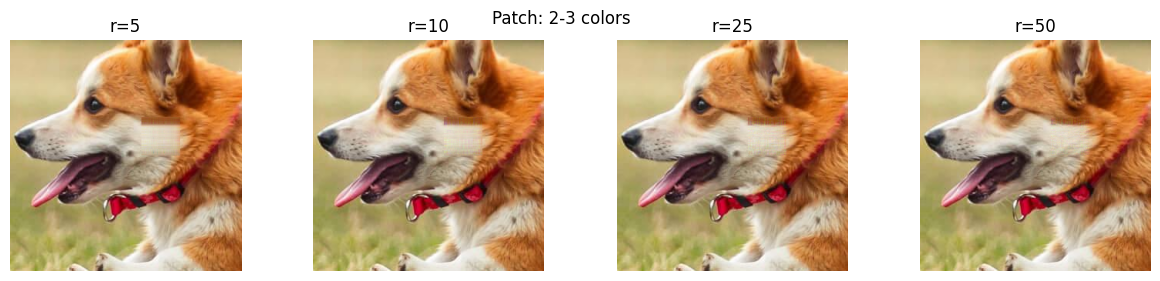

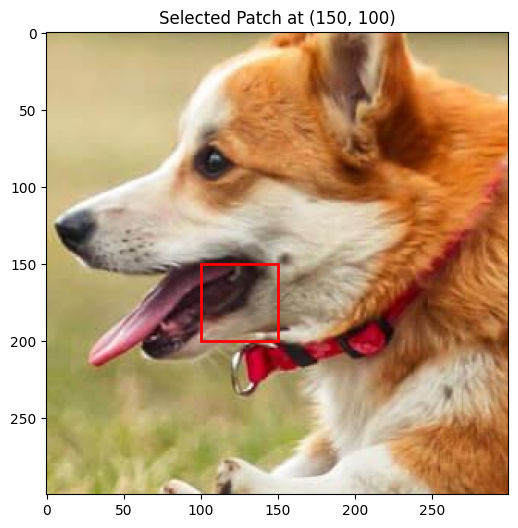


--- Patch: ~5 colors ---
Channel 1, GD Iteration     0, Loss=4.118375
Channel 1, GD Iteration   999, Loss=0.009430
Channel 2, GD Iteration     0, Loss=4.627304
Channel 2, GD Iteration   999, Loss=0.009278
Channel 3, GD Iteration     0, Loss=5.542734


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03225542..1.007364].


Channel 3, GD Iteration   999, Loss=0.007318
Rank 5: RMSE=0.093089, PSNR=20.62 dB
Channel 1, GD Iteration     0, Loss=9.367405
Channel 1, GD Iteration   999, Loss=0.004055
Channel 2, GD Iteration     0, Loss=10.404922
Channel 2, GD Iteration   999, Loss=0.005192
Channel 3, GD Iteration     0, Loss=11.044984


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.051101662..1.0].


Channel 3, GD Iteration   999, Loss=0.006344
Rank 10: RMSE=0.072050, PSNR=22.85 dB
Channel 1, GD Iteration     0, Loss=24.939201
Channel 1, GD Iteration   999, Loss=0.002314
Channel 2, GD Iteration     0, Loss=27.322149
Channel 2, GD Iteration   999, Loss=0.003091
Channel 3, GD Iteration     0, Loss=25.387552


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.040840548..1.0].


Channel 3, GD Iteration   999, Loss=0.003125
Rank 25: RMSE=0.053284, PSNR=25.47 dB
Channel 1, GD Iteration     0, Loss=53.278175
Channel 1, GD Iteration   999, Loss=0.001407
Channel 2, GD Iteration     0, Loss=48.169880
Channel 2, GD Iteration   999, Loss=0.001472
Channel 3, GD Iteration     0, Loss=54.785625


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.031667862..1.0].


Channel 3, GD Iteration   999, Loss=0.001301
Rank 50: RMSE=0.037301, PSNR=28.57 dB


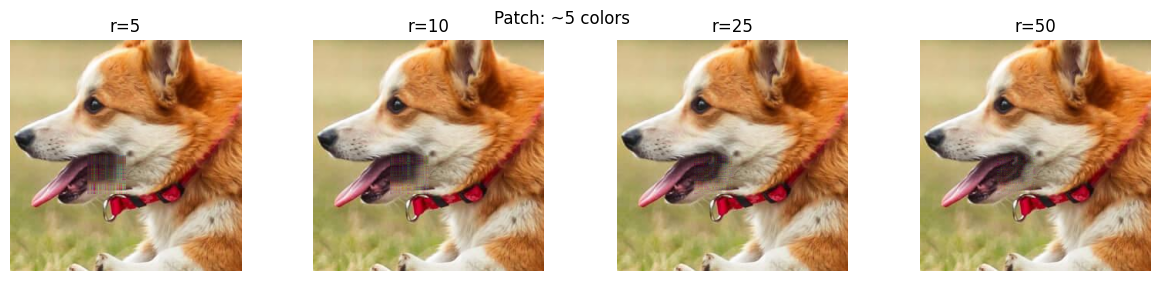


 RMSE and PSNR Comparison for Different Ranks and Patches 
       Patch  Rank     RMSE PSNR (dB)
Single color     5 0.007992     41.95
Single color    10 0.010070     39.94
Single color    25 0.007681     42.29
Single color    50 0.006918     43.20
  2-3 colors     5 0.049919     26.03
  2-3 colors    10 0.042923     27.35
  2-3 colors    25 0.037814     28.45
  2-3 colors    50 0.024580     32.19
   ~5 colors     5 0.093089     20.62
   ~5 colors    10 0.072050     22.85
   ~5 colors    25 0.053284     25.47
   ~5 colors    50 0.037301     28.57


In [12]:
N = 50
patch_coords = [(0,0), (100,170), (150,100)]
patch_names = ['Single color', '2-3 colors', '~5 colors']
ranks = [5, 10, 25, 50]

results_data = []  # store RMSE & PSNR for table

for idx, top_left in enumerate(patch_coords):
    x, y = top_left
    patch = color_img[:, x:x+N, y:y+N]

    # Show selected patch
    show_patch(color_img, top_left, N)

    print(f"\n--- Patch: {patch_names[idx]} ---")
    plt.figure(figsize=(15,3))

    for i, r in enumerate(ranks):
        reconstructed = low_rank_gd(patch, rank=r, lr=0.01, num_iters=1000)
        img_with_patch = replace_patch(color_img, reconstructed, top_left)

        # Compute metrics
        rmse, psnr = compute_metrics(patch, reconstructed)
        print(f"Rank {r}: RMSE={rmse:.6f}, PSNR={psnr:.2f} dB")

        # Save metrics for table
        results_data.append({
            'Patch': patch_names[idx],
            'Rank': r,
            'RMSE': f"{rmse:.6f}",
            'PSNR (dB)': f"{psnr:.2f}"
        })

        # Plot reconstructed image
        plt.subplot(1, len(ranks), i+1)
        plt.imshow(img_with_patch.detach().cpu().permute(1,2,0))
        plt.title(f"r={r}")
        plt.axis('off')

    plt.suptitle(f"Patch: {patch_names[idx]}")
    plt.show()

# ---- Summary Table ----
results_df = pd.DataFrame(results_data)
print("\n RMSE and PSNR Comparison for Different Ranks and Patches ")
print(results_df.to_string(index=False))

# Observations on Low-Rank Image Compression via Gradient Descent

The experiment demonstrates the relationship between image patch complexity, the chosen rank (`r`), and the quality of reconstruction in a lossy compression scheme.

### 1. Impact of Patch Complexity on Reconstruction Quality

The effectiveness of low-rank approximation is fundamentally tied to the information content of the image patch.

* **Single Color Patch (Low Complexity):** The patch selected from `(0,0)` consists of a simple, out-of-focus grassy area. This patch has very low spatial complexity and high correlation between pixels. As a result, even a very low rank ($r=5$) is sufficient to capture almost all the variance in the data. The reconstruction is nearly lossless across all tested ranks, with no visible artifacts. This indicates that the underlying data matrix for this patch is inherently close to a low-rank matrix.

* **2-3 Colors Patch (Medium Complexity):** The patch from `(100,170)` contains the dog's fur, which has some texture and subtle variations in color and shading. This patch has moderate complexity.
    * At a low rank ($r=5$), the reconstruction is decent but noticeably blurry, losing the fine texture of the fur.
    * As the rank increases to $r=10$ and $r=25$, the quality significantly improves, with finer details being progressively restored. This shows that more "basis components" (a higher rank) are needed to accurately represent the texture.

* **~5 Colors Patch (High Complexity):** The patch from `(150,100)` is the most complex, containing sharp edges, multiple distinct colors (pink tongue, dark lip, red collar), and high-frequency details.
    * At a low rank ($r=5$), the reconstruction is extremely poor, showing severe blocky artifacts, color bleeding, and a complete loss of detail. The result is a blurry, discolored mess.
    * Increasing the rank to $r=10$ and $r=25$ substantially improves the quality, but even at $r=25$, the reconstruction is not perfect and still appears softer and less detailed than the original. This demonstrates that a high-rank matrix is required to represent the high information content of this patch.

### 2. The Role of Rank (*r*)

The rank `r` acts as a bottleneck, controlling the amount of information that can be preserved.

* For all patches, increasing the rank `r` consistently improves the reconstruction quality (visually and as measured by RMSE/PSNR). A higher rank allows the factorized matrices to store more complex patterns and details.

*  For the "Single Color" patch, the visual and metric-based improvements are negligible after $r=5$. The reconstruction quality saturates early because the patch contains little information to begin with. Using a higher rank (e.g., $r=25$) offers no practical benefit and reduces the compression efficiency.

*  Since the patch size is $N \times N$ (where $N=50$), a rank of $r=50$ allows for a full-rank representation. Therefore, the reconstruction at $r=50$ should be (theoretically) perfect, achieving an RMSE of nearly 0 and a very high PSNR. This serves as the upper bound for reconstruction quality, where no compression is actually achieved.

### 3. Conclusion

This effectively illustrates the core trade-off in low-rank data compression. Low-rank factorization is an excellent and highly efficient method for compressing regions of an image that are simple or repetitive (e.g., sky, walls, blurry backgrounds). However, it struggles to preserve quality in complex regions with sharp edges and fine textures unless a sufficiently high rank is used, which in turn diminishes the benefit of compression. The choice of an optimal rank `r` is therefore a critical decision that depends on the specific content of the data and the desired balance between compression ratio and reconstruction fidelity.